# Data processing

- Z-score scaler for load and weather parameters
- both sine & cosine function for time feature transformation
- IQR for data cleaning
- 

In [135]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, TimeSeriesSplit
import joblib
import json
import seaborn as sns

import pandas as pd
from skopt import gp_minimize
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, r2_score
from skopt.utils import use_named_args
from skopt.space import Real, Integer, Categorical
import time

In [185]:
# 1. JSON Parser specifically for the API
def parse_json(json_payload):
    """Parses the specific JSON structure into a Pandas DataFrame."""
    times = json_payload['history']['times']
    data_dict = json_payload['history']['data']
    
    # Create DataFrame
    df = pd.DataFrame(data_dict)
    
    # Convert times to datetime and set as index
    df['times'] = pd.to_datetime(times)
    df.set_index('times', inplace=True)
    
    original_len = len(df)
    print(f"Original Data Length (raw rows): {original_len}")
    
    # Enforce 15-minute frequency to expose any completely missing rows
    df = df.asfreq('15min')
    print(f"Length after enforcing 15-minute frequency: {len(df)}")
    
    return df

# 2. Data Processor
# ==========================================
class DataProcessor:
    def __init__(self):
        self.scaler = StandardScaler()
        self.iqr_bounds = {}

        # 1. Explicitly list the exact features you want to KEEP
        self.selected_features = ['shortwave_radiation', 'temperature_2m'] # remove windspeed, less correlated with target
        self.target = ['y']

        # Add the new engineered feature, computed as the historical average of 'y' for the same day of week and hour
        self.engineered_features = ['y_hist_avg']
        
        # Dynamically build the processing lists
        self.scale_cols = self.selected_features + self.target + self.engineered_features
        self.outlier_cols = self.selected_features.copy()
        
        # Define the final output columns 
        self.time_features = ['hour_sin', 'hour_cos', 'dayofweek_sin', 'dayofweek_cos', 'dayofyear_sin', 'dayofyear_cos'] 
        self.flag_features = ['rad_high_flag','temp_high_flag' ,'temp_low_flag', 'is_weekend']
        self.final_columns = self.scale_cols + self.time_features + self.flag_features

        # Based on visual checks of the hisorical data, set a minimum threshold for 'y' to avoid skewing the historical average with extreme low values
        self.y_min_threshold = 3000000

        # Placeholders for our dynamic thresholds learned during fit()
        self.rad_upper_bound = None
        self.temp_lower_bound = None
        self.temp_high_bound = None

    def _time_features(self, df):
        """Extracts cyclical time features from the datetime index."""

        # minute of hour was also tested but not relevant
        # Keeping both sine and coseine improve the model accuracy
        df['hour_sin'] = np.sin(2 * np.pi * df.index.hour / 24)
        df['hour_cos'] = np.cos(2 * np.pi * df.index.hour / 24)
        
        df['dayofweek_sin'] = np.sin(2 * np.pi * df.index.dayofweek / 7)
        df['dayofweek_cos'] = np.cos(2 * np.pi * df.index.dayofweek / 7)
        
        df['dayofyear_sin'] = np.sin(2 * np.pi * df.index.dayofyear / 365)
        df['dayofyear_cos'] = np.cos(2 * np.pi * df.index.dayofyear / 365)

        # Weeked flag: 1 if Saturday or Sunday, 0 otherwise
        df['is_weekend'] = np.where(df.index.dayofweek >= 5, 1, 0)
        
        return df
    
    def fit(self, df): 
        """Calculates flag thresholds, calculates the historical average, and fits the Z-score scaler for training data"""
        df_fit = df.copy()

        # Learn thresholds for flags instead of capping limits
        q1_rad = df_fit['shortwave_radiation'].quantile(0.25)
        q3_rad = df_fit['shortwave_radiation'].quantile(0.75)
        self.rad_upper_bound = q3_rad + 1.5 * (q3_rad - q1_rad)

        self.temp_lower_bound = df_fit['temperature_2m'].quantile(0.05)
        self.temp_high_bound = df_fit['temperature_2m'].quantile(0.95)

        # Interpolate ONLY 'y' to safely build historical averages
        temp_y = df_fit['y'].copy()
        
        # Apply thresholding before building history so anomalies don't drag down the average
        temp_y.loc[temp_y < self.y_min_threshold] = np.nan 
        temp_y = temp_y.interpolate(method='linear').ffill().bfill()
        
        self.global_y_mean = temp_y.mean()
        
        # Create a temporary DataFrame to hold the day of week and hour for grouping
        # If the count of historical values is less than 5, we will use the global mean to avoid skewing the average with too few samples
        temp_df = pd.DataFrame({'y': temp_y, 'dow': temp_y.index.dayofweek, 'hour': temp_y.index.hour})
        grouped = temp_df.groupby(['dow', 'hour'])['y'].agg(['mean', 'count'])
        grouped['y_hist_avg'] = np.where(grouped['count'] < 5, self.global_y_mean, grouped['mean'])
        
        self.y_avg_map = grouped['y_hist_avg'].to_dict()

        # Create the new feature in df_fit so the Scaler can learn its distribution
        keys = list(zip(df_fit.index.dayofweek, df_fit.index.hour))
        df_fit['y_hist_avg'] = [self.y_avg_map.get(k, self.global_y_mean) for k in keys]

        self.scaler.fit(df_fit[self.scale_cols])
        return self

    def transform(self, df):
        """Applies cleaning, scaling, and feature engineering."""
        df = df.copy()
        
        # Apply feature flags BEFORE any interpolation to capture raw anomalies
        if 'shortwave_radiation' in df.columns:
            df['rad_high_flag'] = np.where(df['shortwave_radiation'] > self.rad_upper_bound, 1, 0)
            
        if 'temperature_2m' in df.columns:
            df['temp_low_flag'] = np.where(df['temperature_2m'] < self.temp_lower_bound, 1, 0)
            df['temp_high_flag'] = np.where(df['temperature_2m'] > self.temp_high_bound, 1, 0)

        # Remove specific target anomalies to NaNs right before interpolation
        if 'y' in df.columns:
            df.loc[df['y'] < self.y_min_threshold, 'y'] = np.nan
            
        # Missing Value Inperpolation
        cols_to_interpolate = self.selected_features + self.target
        for col in cols_to_interpolate:
            if col in df.columns:
                df[col] = df[col].interpolate(method='linear')
                df[col] = df[col].ffill().bfill()

        # Map the historical average feature BEFORE scaling
        keys = list(zip(df.index.dayofweek, df.index.hour))
        df['y_hist_avg'] = [self.y_avg_map.get(k, self.global_y_mean) for k in keys]

        # Apply Standard Scaler 
        df[self.scale_cols] = self.scaler.transform(df[self.scale_cols])
        
        # Extract Cyclical Time Features
        df = self._time_features(df)
        
        # STRICT FEATURE SELECTION
        return df[self.final_columns]
    
def build_cv_folds(train_raw_data, n_splits=3):
    """Fit/transform DataProcessor independently per fold. Returns list of 
    (X_tr, y_tr, X_val, y_val) tuples — computed once, reused for every model."""
    tscv = TimeSeriesSplit(n_splits=n_splits)
    folds = []
    
    print("\n--- Generating Leakage-Free CV Folds ---")
    for fold_idx, (tr_idx, val_idx) in enumerate(tscv.split(train_raw_data)):
        fold_train_raw = train_raw_data.iloc[tr_idx]
        fold_val_raw   = train_raw_data.iloc[val_idx]

        fold_processor = DataProcessor()
        fold_processor.fit(fold_train_raw)

        fold_train_clean = fold_processor.transform(fold_train_raw)
        fold_val_clean   = fold_processor.transform(fold_val_raw)

        X_tr = fold_train_clean.drop(columns=['y'])
        y_tr = fold_train_clean['y']
        
        X_val = fold_val_clean.drop(columns=['y'])
        y_val = fold_val_clean['y']
        
        folds.append((X_tr, y_tr, X_val, y_val))
        print(f"Prepared Fold {fold_idx+1}: Train={len(X_tr)} rows | Val={len(X_val)} rows")
        
    return folds

def cv_score(model_class, folds, **model_kwargs):
    """Scores a model across the pre-built, leakage-free folds."""
    scores = []
    for X_tr, y_tr, X_val, y_val in folds:
        model = model_class(**model_kwargs)
        model.fit(X_tr, y_tr)
        preds = model.predict(X_val)
        # We calculate MSE. Lower is better for the Bayesian Optimizer.
        scores.append(mean_squared_error(y_val, preds))
    return np.mean(scores)

--- Parsing Data ---
Original Data Length (raw rows): 9440
Length after enforcing 15-minute frequency: 9440

--- Outlier Detection for Target Variable (y) ---
Found 3 outlier(s) dropping below 3000000:
 - Timestamp: 2023-11-01 23:30:00+00:00 | Value: 1968000.0
 - Timestamp: 2023-11-01 23:45:00+00:00 | Value: 1936000.0
 - Timestamp: 2023-11-02 00:00:00+00:00 | Value: 1968000.0

--- Plotting Full Historical Load (Before vs After) ---


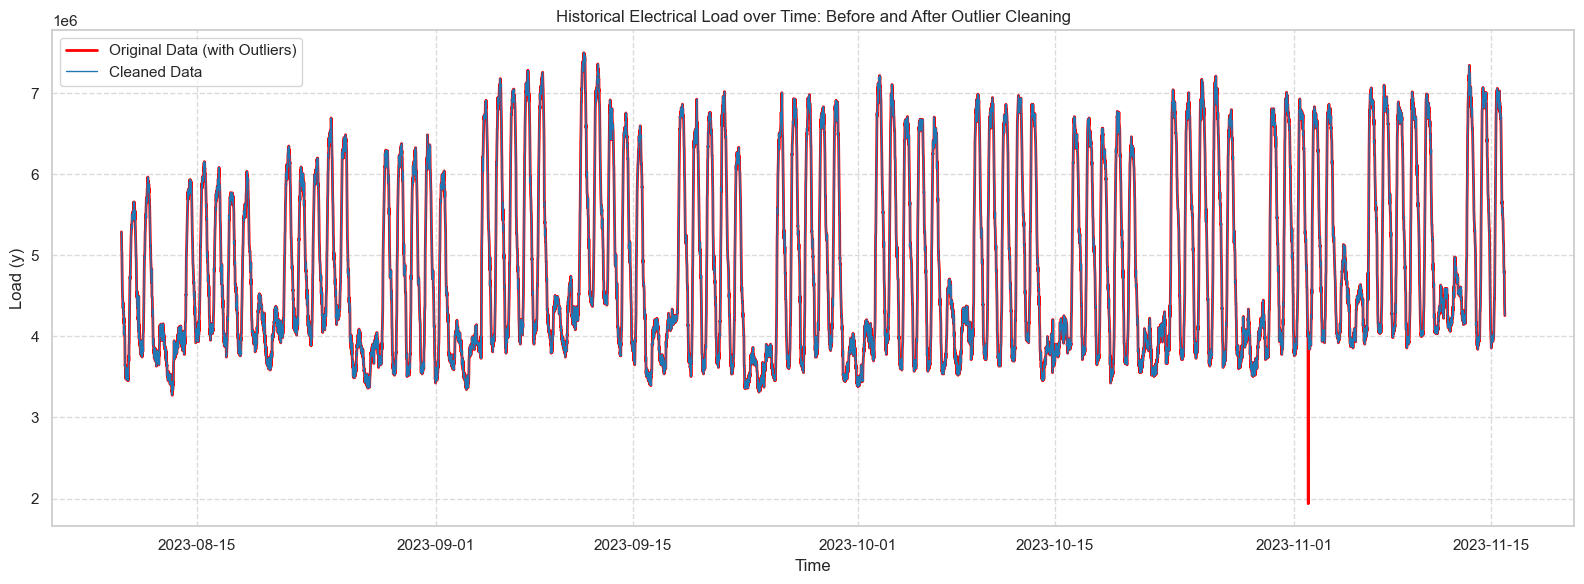

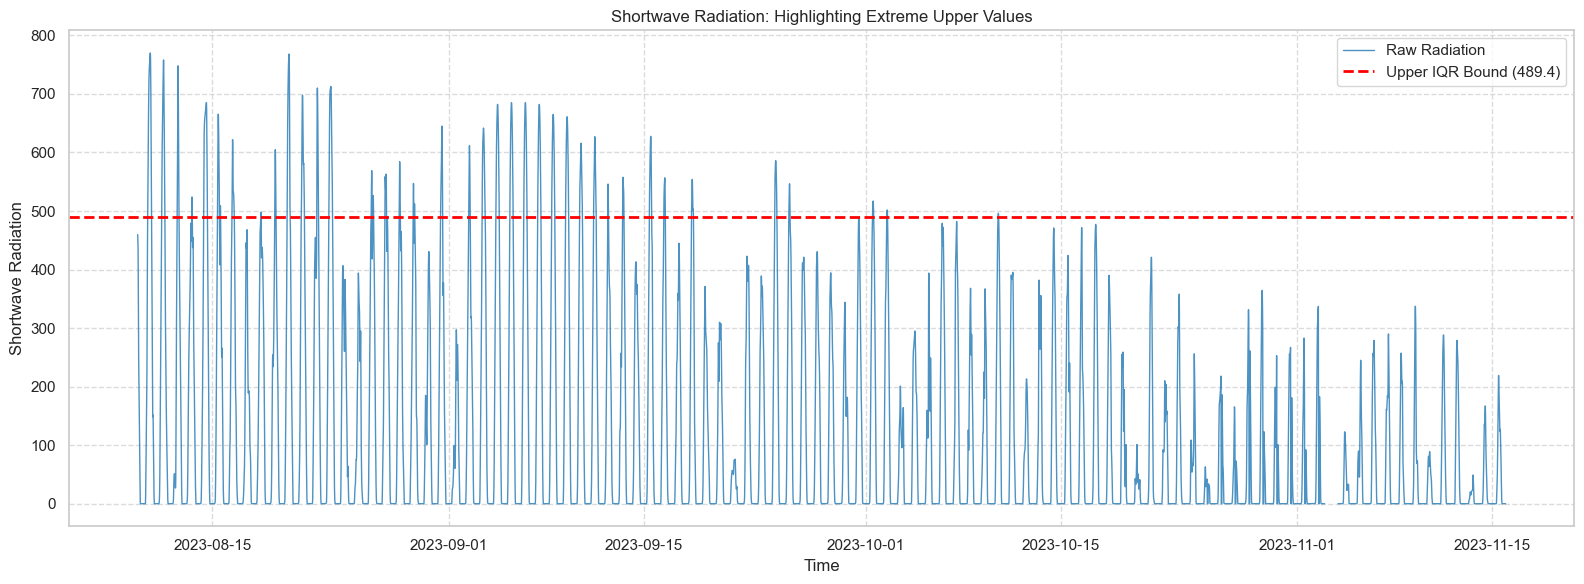

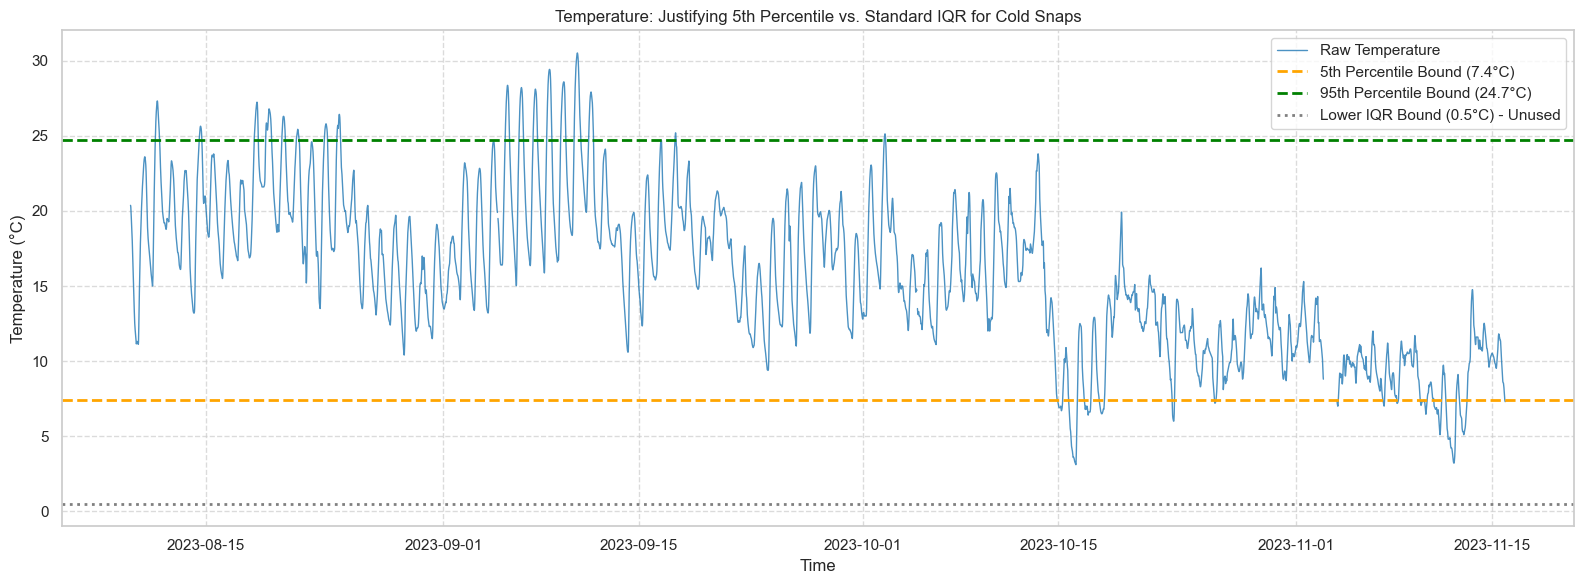


--- Splitting Data ---
Training data shape: (8608, 4)
Testing data shape: (832, 4)
Training Period: 2023-08-09 15:15:00+00:00  TO  2023-11-07 07:00:00+00:00
Testing Period:  2023-11-07 07:15:00+00:00  TO  2023-11-15 23:00:00+00:00

--- Raw Missing Values BEFORE Processing (Train) ---
shortwave_radiation    98
temperature_2m         98
y                      12
dtype: int64

--- Generating Leakage-Free CV Folds ---
Prepared Fold 1: Train=2152 rows | Val=2152 rows
Prepared Fold 2: Train=4304 rows | Val=2152 rows
Prepared Fold 3: Train=6456 rows | Val=2152 rows

--- Cleaned Train DataFrame Head (5) ---
                           shortwave_radiation  temperature_2m         y  \
times                                                                      
2023-08-09 15:15:00+00:00             1.804668        0.784158  0.410589   
2023-08-09 15:30:00+00:00             1.783460        0.777953  0.357317   
2023-08-09 15:45:00+00:00             1.742721        0.762202  0.205831   
2023-08-09 1

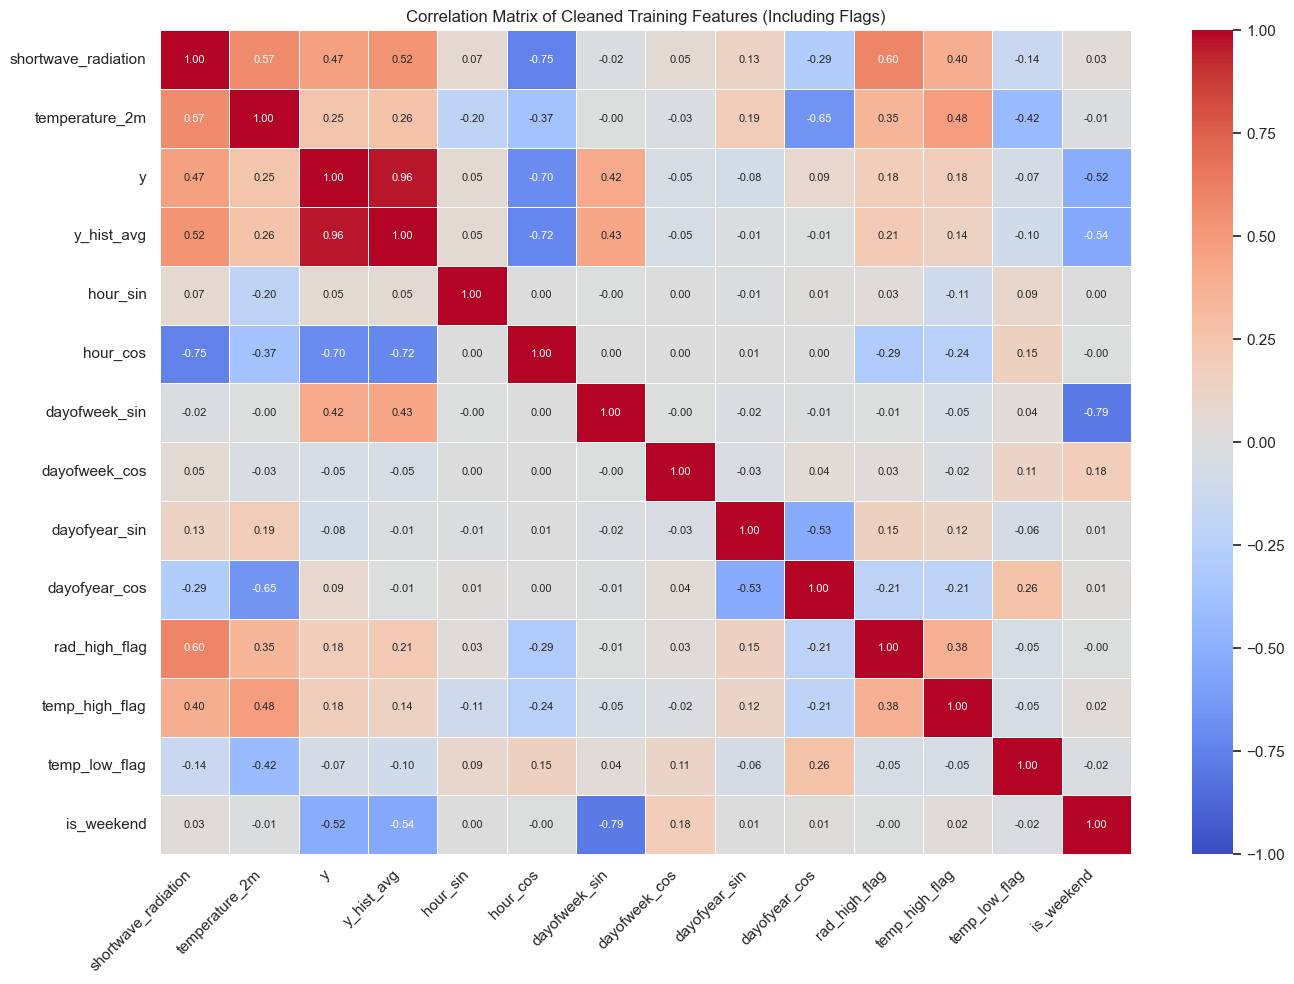

In [186]:
# Test Code Execution
# ==========================================
if __name__ == "__main__":
    
    # 1. DATA INGESTION
    with open("request_body (1).json", "r") as f:
        payload = json.load(f)

    print("--- Parsing Data ---")
    raw_df = parse_json(payload)

    # 2. EXPLORATORY DATA ANALYSIS (EDA) & TARGET VALIDATION
    print("\n--- Outlier Detection for Target Variable (y) ---")
    Y_MIN_THRESHOLD = 3000000 
    
    outlier_mask = raw_df['y'] < Y_MIN_THRESHOLD
    outlier_timestamps = raw_df[outlier_mask].index
    
    print(f"Found {len(outlier_timestamps)} outlier(s) dropping below {Y_MIN_THRESHOLD}:")
    for ts in outlier_timestamps:
        print(f" - Timestamp: {ts} | Value: {raw_df.loc[ts, 'y']}")
        
    # Create a temporary series just for the plot so we don't leak into raw_df
    original_y = raw_df['y'].copy()
    plot_cleaned_y = original_y.copy()
    plot_cleaned_y.loc[outlier_mask] = np.nan
    plot_cleaned_y = plot_cleaned_y.interpolate(method='linear')
    
    # Plot Full Historical Load
    print("\n--- Plotting Full Historical Load (Before vs After) ---") 
    plt.figure(figsize=(16, 6))
    plt.plot(original_y.index, original_y, color='red', linewidth=2, label='Original Data (with Outliers)')
    plt.plot(plot_cleaned_y.index, plot_cleaned_y, color='#1f77b4', linewidth=1, label='Cleaned Data')
    
    plt.title("Historical Electrical Load over Time: Before and After Outlier Cleaning")
    plt.xlabel("Time")
    plt.ylabel("Load (y)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # WEATHER FEATURE ENGINEERING JUSTIFICATION PLOTS
    # 1. Shortwave Radiation Plot (Upper IQR Flag)
    q1_rad = raw_df['shortwave_radiation'].quantile(0.25)
    q3_rad = raw_df['shortwave_radiation'].quantile(0.75)
    rad_upper_bound = q3_rad + 1.5 * (q3_rad - q1_rad)
    
    # Isolate flagged points for plotting
    rad_flagged = raw_df[raw_df['shortwave_radiation'] > rad_upper_bound]
    
    plt.figure(figsize=(16, 6))
    plt.plot(raw_df.index, raw_df['shortwave_radiation'], color='#1f77b4', linewidth=1, label='Raw Radiation', alpha=0.8)
    plt.axhline(rad_upper_bound, color='red', linestyle='--', linewidth=2, label=f'Upper IQR Bound ({rad_upper_bound:.1f})')
    
    plt.title("Shortwave Radiation: Highlighting Extreme Upper Values")
    plt.xlabel("Time")
    plt.ylabel("Shortwave Radiation")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # 2. Temperature Plot (5th Percentile vs IQR)
    temp_p05 = raw_df['temperature_2m'].quantile(0.05)
    temp_p95 = raw_df['temperature_2m'].quantile(0.95)
    q1_temp = raw_df['temperature_2m'].quantile(0.25)
    q3_temp = raw_df['temperature_2m'].quantile(0.75)
    temp_lower_iqr = q1_temp - 1.5 * (q3_temp - q1_temp)

    plt.figure(figsize=(16, 6))
    plt.plot(raw_df.index, raw_df['temperature_2m'], color='#1f77b4', linewidth=1, label='Raw Temperature', alpha=0.8)
    
    # Draw the effective 5th percentile bound
    plt.axhline(temp_p05, color='orange', linestyle='--', linewidth=2, label=f'5th Percentile Bound ({temp_p05:.1f}°C)')
    plt.axhline(temp_p95, color='green', linestyle='--', linewidth=2, label=f'95th Percentile Bound ({temp_p95:.1f}°C)')
    # Draw the ineffective IQR lower bound for visual justification
    plt.axhline(temp_lower_iqr, color='gray', linestyle=':', linewidth=2, label=f'Lower IQR Bound ({temp_lower_iqr:.1f}°C) - Unused')
    
    plt.title("Temperature: Justifying 5th Percentile vs. Standard IQR for Cold Snaps")
    plt.xlabel("Time")
    plt.ylabel("Temperature (°C)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # 3. CHRONOLOGICAL SPLIT (No modifications to raw_df)
    print("\n--- Splitting Data ---")
    train_raw, test_raw = train_test_split(raw_df, test_size=832, shuffle=False)
    print(f"Training data shape: {train_raw.shape}")
    print(f"Testing data shape: {test_raw.shape}")
    
    print(f"Training Period: {train_raw.index.min()}  TO  {train_raw.index.max()}")
    print(f"Testing Period:  {test_raw.index.min()}  TO  {test_raw.index.max()}")
    print("\n--- Raw Missing Values BEFORE Processing (Train) ---")
    print(train_raw[['shortwave_radiation', 'temperature_2m', 'y']].isna().sum())

    # 4. CROSS-VALIDATION FOLD PREPARATION
    # Build the folds ONCE for your Bayesian Optimizer
    folds = build_cv_folds(train_raw, n_splits=3)

    # 5. FINAL TEST SET PREPARATION
    processor = DataProcessor()
    processor.fit(train_raw) 
    train_clean = processor.transform(train_raw)
    test_clean = processor.transform(test_raw)
    print("\n--- Cleaned Train DataFrame Head (5) ---")
    print(train_clean.head(5))

    # 6. FEATURE CORRELATION CHECK
    corr = train_clean.select_dtypes(include=[np.number]).corr()

    plt.figure(figsize=(14, 10))
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        linewidths=0.5,
        annot_kws={"size": 8},
    )
    plt.title("Correlation Matrix of Cleaned Training Features (Including Flags)")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # 7. FINAL ARRAYS FOR MODELING
    X_train = train_clean.drop(columns=['y'])
    y_train = train_clean['y']

    X_test = test_clean.drop(columns=['y'])
    y_test = test_clean['y']

    # Scaling back the predictions to original units for metrics calculation
    # NOTE: Ensure the index matches the location of 'y' in self.scale_cols inside DataProcessor
    y_idx = processor.scale_cols.index('y')
    y_std_watts = processor.scaler.scale_[y_idx]
    y_mean_watts = processor.scaler.mean_[y_idx]
    
    max_load_watts = train_raw['y'].max()
    max_load_kw = max_load_watts / 1000

# Model Training & Validation
- investigated models: RF, XGBoost, MLR, Poly, MLP
- Bayesian optimization with 3-fold CV to tune hyperparameters for RF, XGBoost, MLP
- Evaluation metrics: MAE, RMSE, NRMSE, R2

In [5]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: xgboost in c:\users\vivi6\anaconda3\lib\site-packages (3.1.2)



In [191]:
rf_space = [
    Integer(50, 500, name='n_estimators'),
    Integer(3, 15, name='max_depth'),
    Integer(2, 10, name='min_samples_split'),
    Integer(1, 5, name='min_samples_leaf'),
    Categorical([1.0, 'sqrt'], name='max_features') # Note: 1.0 replaces None for max_features in recent sklearn
]

# The objective function the Bayesian optimizer will try to minimize
@use_named_args(rf_space)
def rf_objective(**params):
    return cv_score(RandomForestRegressor, folds, random_state=42, **params)

rf_start_total = time.time()
# gp_minimize is the engine that powers BayesSearchCV
rf_res = gp_minimize(rf_objective, rf_space, n_calls=30, random_state=42)
rf_end_total = time.time()
rf_tuned_time = rf_end_total - rf_start_total
print(f"Total RF Optimization Time: {rf_tuned_time:.2f} seconds")

# Convert the optimal results list back into a dictionary
best_rf_params = {dim.name: val for dim, val in zip(rf_space, rf_res.x)}
print(f"Best RF Parameters: {best_rf_params}")
print(f"Best RF CV Score (MSE): {rf_res.fun:.4f}")

Total RF Optimization Time: 149.63 seconds
Best RF Parameters: {'n_estimators': 56, 'max_depth': 14, 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 1.0}
Best RF CV Score (MSE): 0.1227


In [192]:
# Evaluate on the locked-away test set
rf_best = RandomForestRegressor(**best_rf_params, random_state=42)
rf_best.fit(X_train, y_train)
rf_start_test = time.perf_counter()
rf_preds = rf_best.predict(X_test)
rf_end_test = time.perf_counter()
rf_test_time = rf_end_test - rf_start_test
print(f"RF Prediction Time: {rf_test_time:.6f} seconds")


rf_rmse_kw = (root_mean_squared_error(y_test, rf_preds) * y_std_watts) / 1000
print(f"RF Test MAE: {(mean_absolute_error(y_test, rf_preds) * y_std_watts) / 1000:.4f} kW")
print(f"RF Test RMSE: {rf_rmse_kw:.4f} kW | NRMSE: {(rf_rmse_kw / max_load_kw):.4f} | R²: {r2_score(y_test, rf_preds):.4f}")

RF Prediction Time: 0.006167 seconds
RF Test MAE: 164.4380 kW
RF Test RMSE: 220.9624 kW | NRMSE: 0.0295 | R²: 0.9620


In [193]:
xgb_space = [
    Integer(50, 700, name='n_estimators'),
    Integer(3, 10, name='max_depth'),
    Real(0.01, 0.3, prior='log-uniform', name='learning_rate'),
    Real(0.5, 1.0, name='subsample'),
    Real(0.5, 1.0, name='colsample_bytree'),
    Integer(1, 20, name='min_child_weight')
]

@use_named_args(xgb_space)
def xgb_objective(**params):
    return cv_score(xgb.XGBRegressor, folds, objective='reg:squarederror', random_state=42, tree_method='exact', **params)

xgb_start_total = time.time()
xgb_res = gp_minimize(xgb_objective, xgb_space, n_calls=30, random_state=42)
xgb_end_total = time.time()
xgb_tuned_time = xgb_end_total - xgb_start_total
print(f"Total XGB Optimization Time: {xgb_tuned_time:.2f} seconds")

best_xgb_params = {dim.name: val for dim, val in zip(xgb_space, xgb_res.x)}
print(f"Best XGB Parameters: {best_xgb_params}")


Total XGB Optimization Time: 74.80 seconds
Best XGB Parameters: {'n_estimators': 523, 'max_depth': 5, 'learning_rate': 0.0696009102198762, 'subsample': 0.7604171300129119, 'colsample_bytree': 0.9805860121746747, 'min_child_weight': 17}


In [194]:
xgb_best = xgb.XGBRegressor(**best_xgb_params, objective='reg:squarederror', random_state=42, tree_method='exact')
xgb_best.fit(X_train, y_train)
xgb_start_test = time.perf_counter()
xgb_preds = xgb_best.predict(X_test)
xgb_end_test = time.perf_counter()
xgb_test_time = xgb_end_test - xgb_start_test
print(f"XGB Prediction Time: {xgb_test_time:.6f} seconds")

xgb_rmse_kw = (root_mean_squared_error(y_test, xgb_preds) * y_std_watts) / 1000
print(f"XGB Test MAE: {(mean_absolute_error(y_test, xgb_preds) * y_std_watts) / 1000:.4f} kW")
print(f"XGB Test RMSE: {xgb_rmse_kw:.4f} kW | NRMSE: {xgb_rmse_kw / max_load_kw:.4f} | R²: {r2_score(y_test, xgb_preds):.4f}")

XGB Prediction Time: 0.005660 seconds
XGB Test MAE: 180.6458 kW
XGB Test RMSE: 238.9519 kW | NRMSE: 0.0319 | R²: 0.9556


In [190]:
poly = PolynomialFeatures(degree=2)
x_poly_train = poly.fit_transform(X_train)

lin_poly = LinearRegression()
start_poly_train = time.time()
lin_poly.fit(x_poly_train, y_train)
end_poly_train = time.time()
poly_train_time = end_poly_train - start_poly_train
print(f"Poly Training Time: {poly_train_time:.6f} seconds")

x_poly_test = poly.transform(X_test)
poly_start_test = time.perf_counter()
poly_preds = lin_poly.predict(x_poly_test)
poly_end_test = time.perf_counter()
poly_test_time = poly_end_test - poly_start_test
print(f"Poly Prediction Time: {poly_test_time:.6f} seconds")

poly_rmse_kw = (root_mean_squared_error(y_test, poly_preds) * y_std_watts) / 1000
print(f"Poly Test MAE: {(mean_absolute_error(y_test, poly_preds) * y_std_watts) / 1000:.4f} kW")
print(f"Poly Test RMSE: {poly_rmse_kw:.4f} kW | NRMSE: {poly_rmse_kw / max_load_kw:.4f} | R²: {r2_score(y_test, poly_preds):.4f}")

Poly Training Time: 0.053312 seconds
Poly Prediction Time: 0.000471 seconds
Poly Test MAE: 233.9352 kW
Poly Test RMSE: 296.0039 kW | NRMSE: 0.0395 | R²: 0.9318


In [169]:
mlr = PolynomialFeatures(degree=1)
x_mlr_train = mlr.fit_transform(X_train)

lin_mlr = LinearRegression()
start_mlr_train = time.time()
lin_mlr.fit(x_mlr_train, y_train)
end_mlr_train = time.time()
mlr_train_time = end_mlr_train - start_mlr_train
print(f"MLR Training Time: {mlr_train_time:.6f} seconds")

x_mlr_test = mlr.transform(X_test)
mlr_start_test = time.perf_counter()
mlr_preds = lin_mlr.predict(x_mlr_test)
mlr_end_test = time.perf_counter()
mlr_test_time = mlr_end_test - mlr_start_test
print(f"MLR Prediction Time: {mlr_test_time:.6f} seconds")

mlr_rmse_kw = (root_mean_squared_error(y_test, mlr_preds) * y_std_watts) / 1000
print(f"MLR Test MAE: {(mean_absolute_error(y_test, mlr_preds) * y_std_watts) / 1000:.4f} kW")
print(f"MLR Test RMSE: {mlr_rmse_kw:.4f} kW | NRMSE: {mlr_rmse_kw / max_load_kw:.4f} | R²: {r2_score(y_test, mlr_preds):.4f}")

MLR Training Time: 0.006046 seconds
MLR Prediction Time: 0.001161 seconds
MLR Test MAE: 307.4740 kW
MLR Test RMSE: 377.0914 kW | NRMSE: 0.0503 | R²: 0.8894


In [187]:
# 1. Define the architectures in a list
mlp_architectures = [
    (8, 16), (16, 8), (16, 16), 
    (8, 8, 8), (32, 16, 8), (16, 16, 8), (16, 16, 16), (32, 32, 16)
]

# 2. Tell skopt to search through indexes (0 through 7) instead of the tuples directly
mlp_space = [
    Integer(0, len(mlp_architectures) - 1, name='arch_idx'),
    Categorical([0.001, 0.0001], name='learning_rate_init'),
    Categorical([0.001, 0.01, 1.0], name='alpha')
]

@use_named_args(mlp_space)
def mlp_objective(arch_idx, learning_rate_init, alpha):
    # Map the index back to the actual tuple for training
    hidden_layer_sizes = mlp_architectures[arch_idx]
    
    return cv_score(
        MLPRegressor, 
        folds, 
        hidden_layer_sizes=hidden_layer_sizes,
        learning_rate_init=learning_rate_init,
        alpha=alpha,
        activation='relu', 
        solver='adam', 
        max_iter=1000, 
        random_state=42, 
        early_stopping=True
    )

mlp_start_total = time.time()
mlp_res = gp_minimize(mlp_objective, mlp_space, n_calls=30, random_state=42)
mlp_end_total = time.time()
mlp_tuned_time = mlp_end_total - mlp_start_total
print(f"Total MLP Optimization Time: {mlp_tuned_time:.2f} seconds")

# 3. Rebuild the final parameters by mapping the best index back to the tuple
best_mlp_params = {dim.name: val for dim, val in zip(mlp_space, mlp_res.x)}
best_arch_idx = best_mlp_params.pop('arch_idx') # Remove the index
best_mlp_params['hidden_layer_sizes'] = mlp_architectures[best_arch_idx] # Insert the actual tuple

print(f"Best MLP Parameters: {best_mlp_params}")

Total MLP Optimization Time: 121.25 seconds
Best MLP Parameters: {'learning_rate_init': 0.001, 'alpha': 1.0, 'hidden_layer_sizes': (16, 16)}


In [188]:
mlp_best = MLPRegressor(**best_mlp_params, activation='relu', solver='adam', max_iter=5000, random_state=42, early_stopping=True)
mlp_best.fit(X_train, y_train)
mlp_start_test = time.perf_counter()
mlp_preds = mlp_best.predict(X_test)
mlp_end_test = time.perf_counter()
mlp_test_time = mlp_end_test - mlp_start_test
print(f"MLP Prediction Time: {mlp_test_time:.6f} seconds")

mlp_rmse_kw = (root_mean_squared_error(y_test, mlp_preds) * y_std_watts) / 1000
print(f"MLP Test MAE: {(mean_absolute_error(y_test, mlp_preds) * y_std_watts) / 1000:.4f} kW")
print(f"MLP Test RMSE: {mlp_rmse_kw:.4f} kW | NRMSE: {mlp_rmse_kw / max_load_kw:.4f} | R²: {r2_score(y_test, mlp_preds):.4f}")

MLP Prediction Time: 0.001240 seconds
MLP Test MAE: 210.7817 kW
MLP Test RMSE: 284.0188 kW | NRMSE: 0.0379 | R²: 0.9373


# Model Analysis

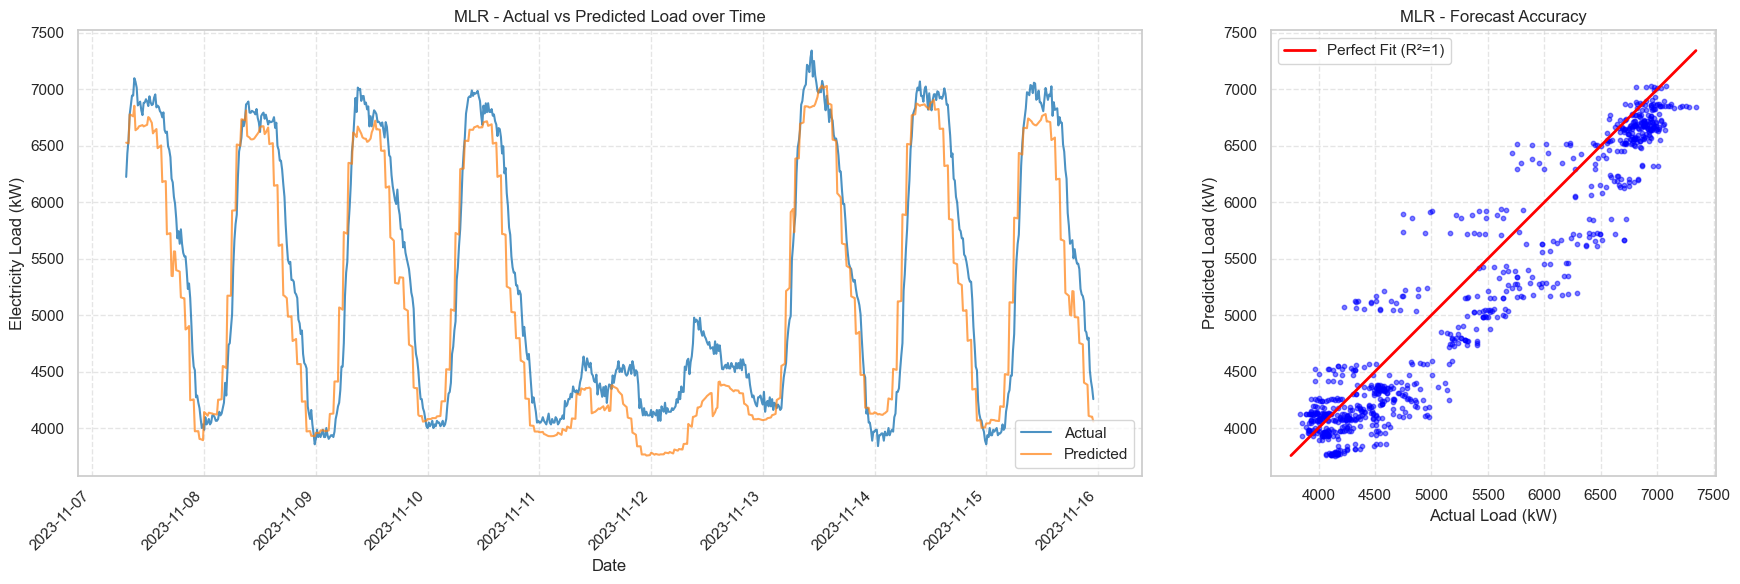

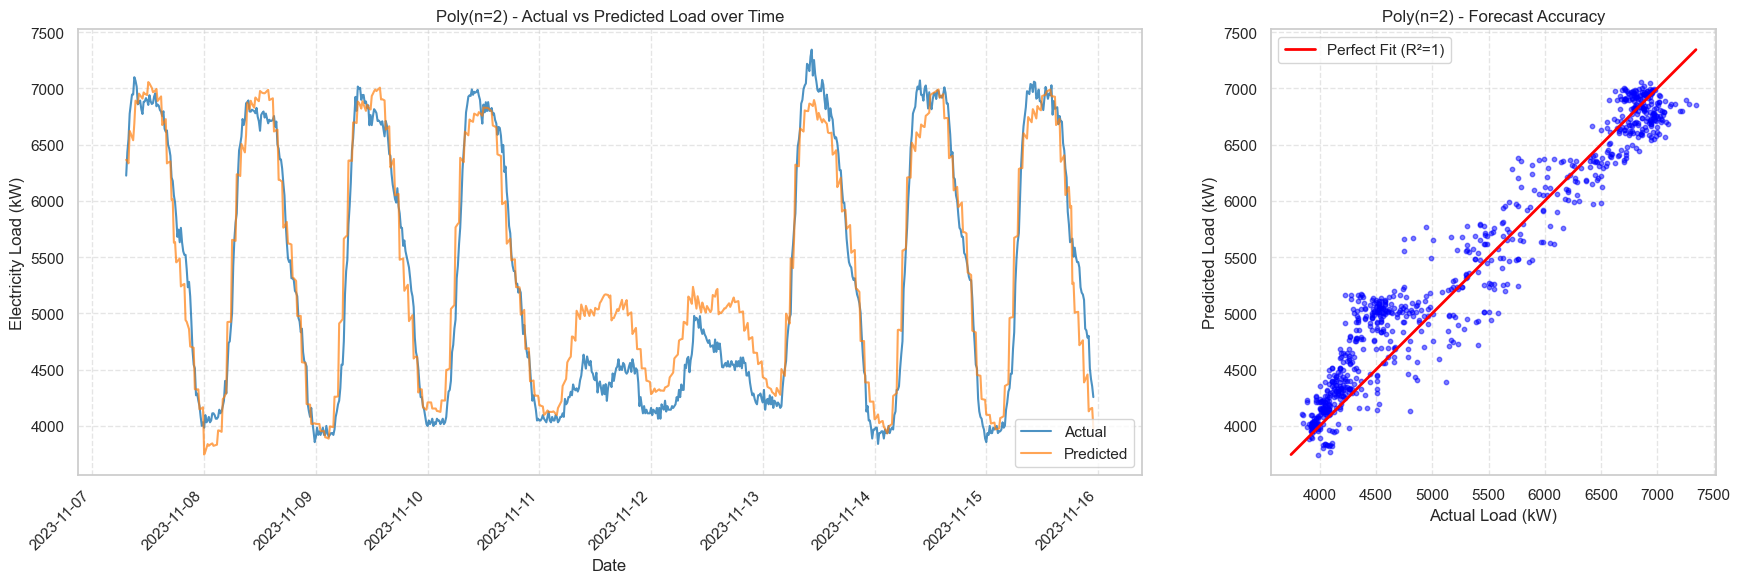

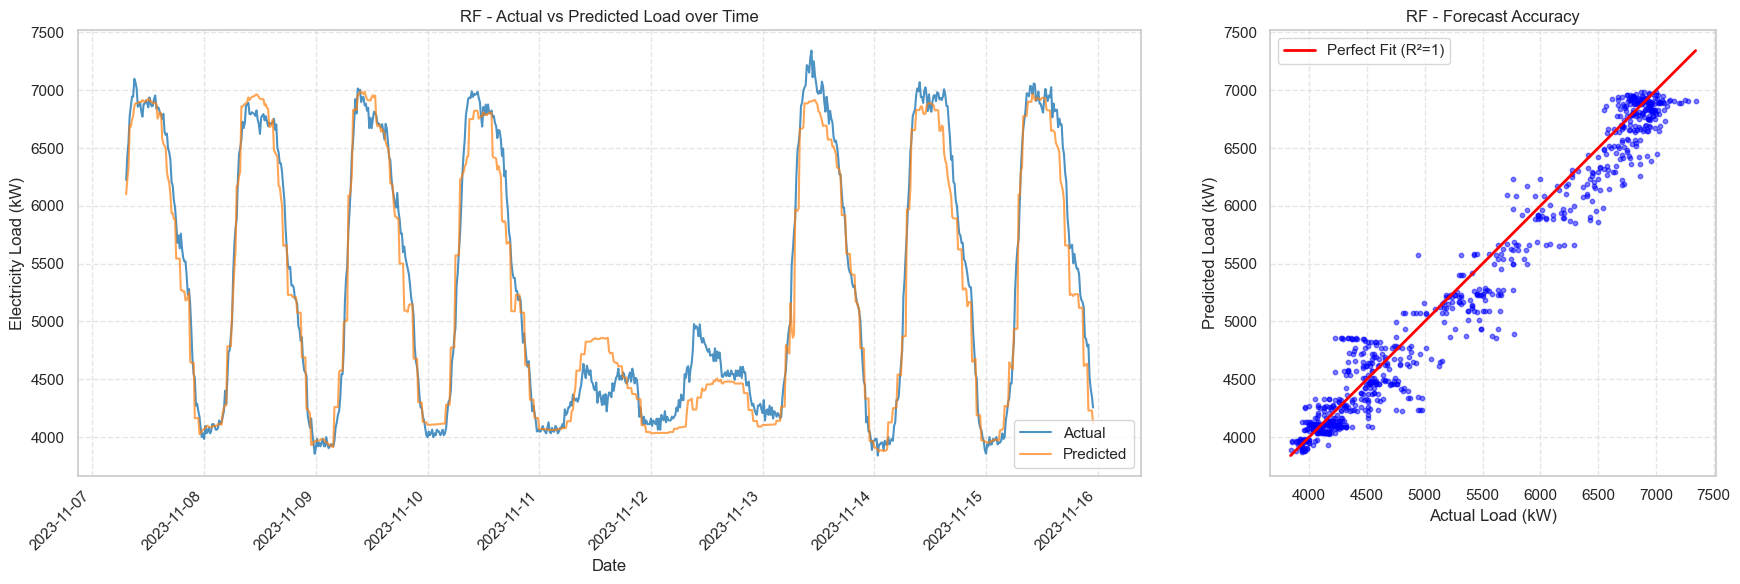

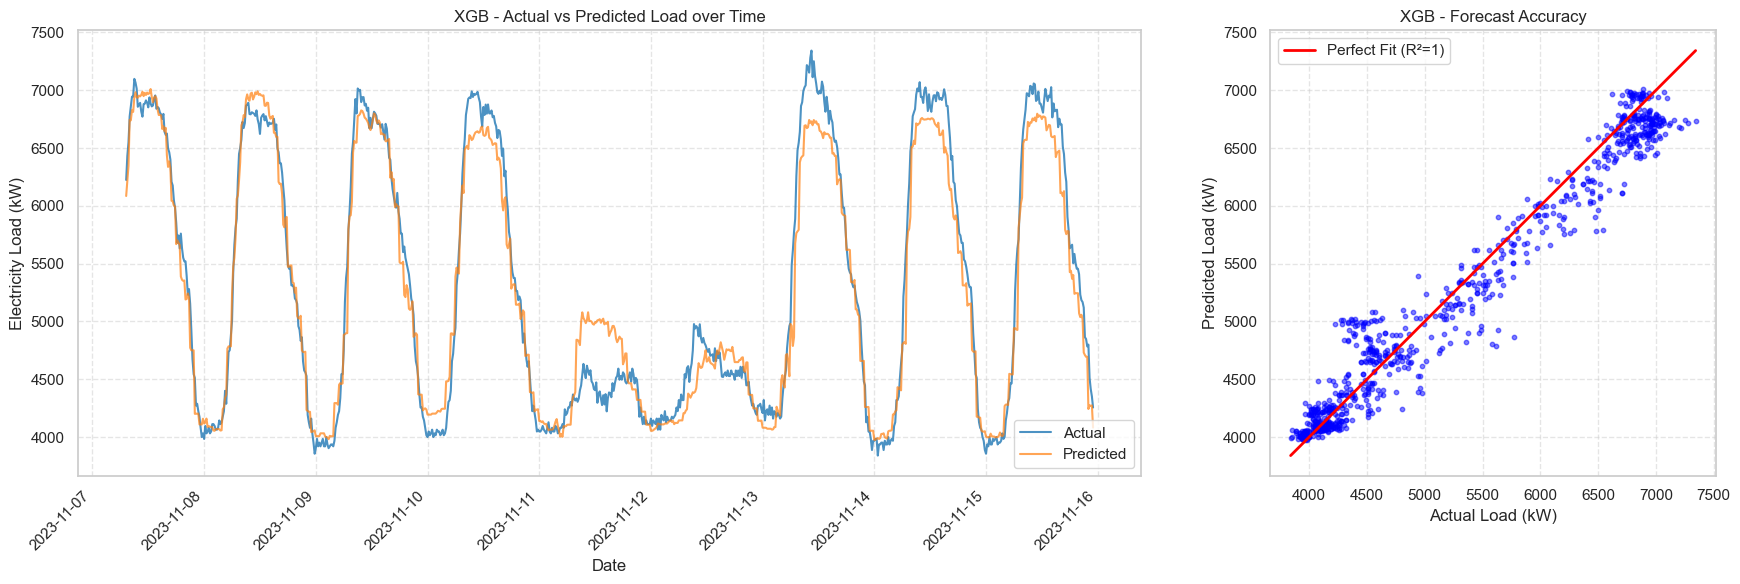

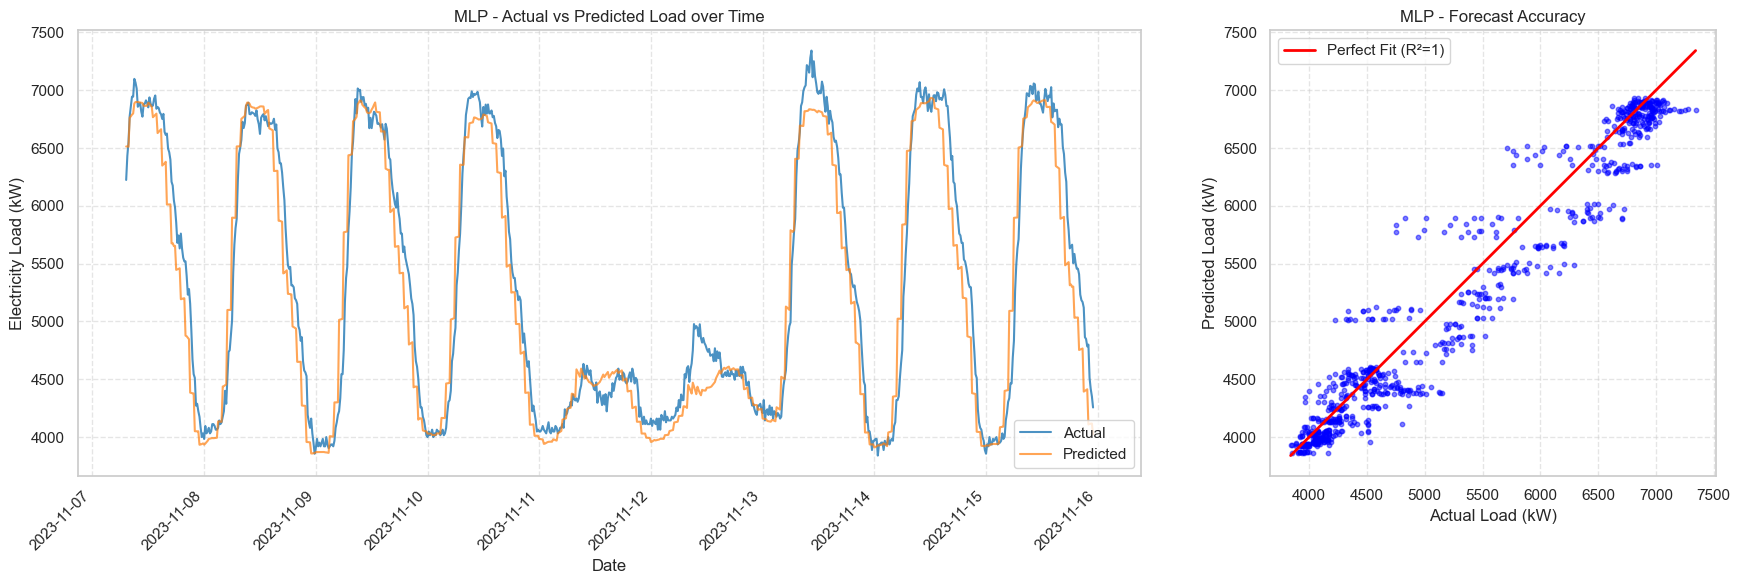

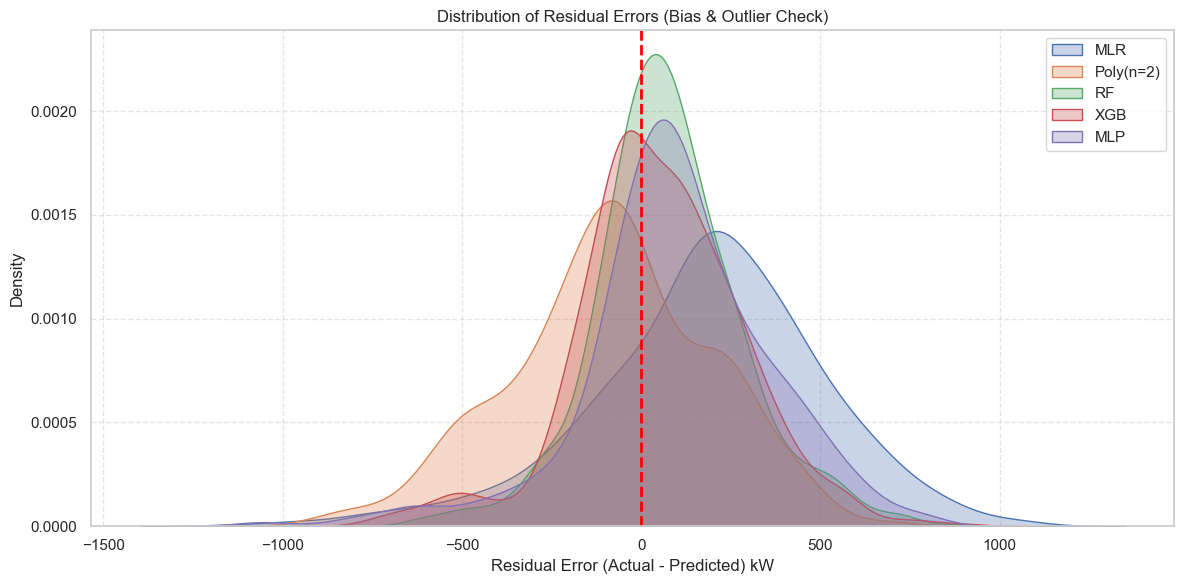

In [195]:
# 1. Consolidate Data & Convert back to real kW
# Math: Original = (Scaled * Std) + Mean
y_test_kw = ((y_test * y_std_watts) + y_mean_watts) / 1000

model_preds = {
    'MLR': ((mlr_preds * y_std_watts) + y_mean_watts) / 1000,
    'Poly(n=2)': ((poly_preds * y_std_watts) + y_mean_watts) / 1000,
    'RF': ((rf_preds * y_std_watts) + y_mean_watts) / 1000,
    'XGB': ((xgb_preds * y_std_watts) + y_mean_watts) / 1000,
    'MLP': ((mlp_preds * y_std_watts) + y_mean_watts) / 1000
}

# Ensure these variable names match exactly what you named your timing variables
model_times = {
    'MLR': mlr_train_time,
    'Poly(n=2)': poly_train_time,
    'RF': rf_tuned_time, 
    'XGB': xgb_tuned_time,       
    'MLP': mlp_tuned_time  
}

# Note: If your RMSE was calculated on the improperly scaled data, 
# you will want to re-run your evaluation block so these match the corrected kW values!
model_rmses = {
    'MLR': mlr_rmse_kw,
    'Poly(n=2)': poly_rmse_kw,
    'RF': rf_rmse_kw,
    'XGB': xgb_rmse_kw,
    'MLP': mlp_rmse_kw
}

# Calculate Residuals (Error = Actual - Predicted)
model_residuals = {name: (y_test_kw - preds) for name, preds in model_preds.items()}

# ==========================================
# Plot 1: Predicted vs Actual (Time-Series & Scatter)
# ==========================================
for name, preds in model_preds.items():
    fig, axes = plt.subplots(1, 2, figsize=(18, 6), gridspec_kw={'width_ratios': [2, 1]})
    
    # 1A. Time Series Comparison
    axes[0].plot(test_raw.index, y_test_kw, label='Actual', color='#1f77b4', alpha=0.8, linewidth=1.5)
    axes[0].plot(test_raw.index, preds, label='Predicted', color='#ff7f0e', alpha=0.7, linewidth=1.5)
    axes[0].set_title(f"{name} - Actual vs Predicted Load over Time")
    axes[0].set_xlabel("Date")
    axes[0].set_ylabel("Electricity Load (kW)")
    axes[0].legend(loc='lower right')
    axes[0].grid(True, linestyle='--', alpha=0.5)
    
    # Format x-axis for dates
    axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha='right')

    # 1B. Actual vs Predicted Scatter with R2=1 Line
    min_val = min(y_test_kw.min(), preds.min())
    max_val = max(y_test_kw.max(), preds.max())
    
    axes[1].scatter(y_test_kw, preds, color='blue', alpha=0.5, s=10)
    axes[1].plot([min_val, max_val], [min_val, max_val], color='red', linewidth=2, label='Perfect Fit (R²=1)')
    axes[1].set_title(f"{name} - Forecast Accuracy")
    axes[1].set_xlabel("Actual Load (kW)")
    axes[1].set_ylabel("Predicted Load (kW)")
    axes[1].set_aspect('equal', adjustable='box')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

# Error Distribution Histogram
# ==========================================
plt.figure(figsize=(12, 6))
for name, resids in model_residuals.items():
    sns.kdeplot(resids, fill=True, alpha=0.3, label=name)

plt.axvline(0, color='red', linestyle='--', linewidth=2)
plt.title("Distribution of Residual Errors (Bias & Outlier Check)")
plt.xlabel("Residual Error (Actual - Predicted) kW")
plt.ylabel("Density")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [196]:
joblib.dump(rf_best, 'best_rf_model.pkl')
joblib.dump(processor, 'data_processor.pkl')
print("Model and processor saved successfully!")

Model and processor saved successfully!
